# EDA (Beauty)

In [2]:
import pandas as pd
import json
import gzip
from typing import Any
import matplotlib.pyplot as plt

In [3]:
# --- Config ---
TARGET_CATEGORY: str = "Beauty_and_Personal_Care"
DATA_DIR: str = "../data"

# Only include reviews that satisfy all of the following criteria
START_DATE: str | None = "2021-01-01"
END_DATE: str | None = "2022-12-31"
MIN_RATING: int | None = None

# Data split cutoff dates
TRAIN_END_CUTOFF_DATE: str = "2022-08-01"
VALID_END_CUTOFF_DATE: str = "2022-10-01"

# User review count thresholds
USER_MIN_REVIEWS: int = 5
WARM_USER_MIN_REVIEWS: int = 10

## Common utils

In [4]:
def stream_jsonl(path: str, fields: list[str] | None = None):
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for _, line in enumerate(f):
            obj = json.loads(line)
            if fields is not None:
                obj = {k: obj.get(k) for k in fields}
            yield obj

def _date_to_ms(date_str: str | None) -> int | None:
    if date_str is None:
        return None
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)

def load_reviews(
    categories: list[str], start_date: str | None = None, end_date: str | None = None, 
    min_rating: int | None = None
) -> list[dict[str, Any]]:
    start_ts = _date_to_ms(start_date)
    end_ts = _date_to_ms(end_date)
    print(f"Filtering reviews with criteria: start_date={start_date}, end_date={end_date}, min_rating={min_rating}")

    reviews: list[dict[str, Any]] = []
    for cat in categories:
        path = f"{DATA_DIR}/{cat}.jsonl.gz"
        print(f"Loading reviews: {path}")
        for obj in stream_jsonl(path, fields=[
            'user_id', 'parent_asin', 'rating', 'timestamp'
        ]):
            ts: Any = obj.get("timestamp")
            rating: Any = obj.get("rating")
            if start_ts is not None and (ts is not None and ts < start_ts):
                continue
            if end_ts is not None and (ts is not None and ts > end_ts):
                continue
            if min_rating is not None and (rating is not None and rating < min_rating):
                continue
            obj["category"] = cat
            reviews.append(obj)
    return reviews


## Load reviews

In [13]:
reviews = load_reviews(
    [TARGET_CATEGORY], start_date=START_DATE, end_date=END_DATE,
    min_rating=MIN_RATING
)
print(f"Loaded {len(reviews)} reviews")

Filtering reviews with criteria: start_date=2021-01-01, end_date=2022-12-31, min_rating=None
Loading reviews: ../data/Beauty_and_Personal_Care.jsonl.gz
Loaded 7395872 reviews


In [14]:
df_reviews = pd.DataFrame(reviews)
display(df_reviews.head())
df_reviews.info()

,user_id,parent_asin,rating,timestamp,category
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00Z03RC80,1.0,1616743454733,Beauty_and_Personal_Care
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B085PRT2MP,1.0,1614915977684,Beauty_and_Personal_Care
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B08G81QQ9L,5.0,1612052493701,Beauty_and_Personal_Care
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07YYG76X1,1.0,1609700981786,Beauty_and_Personal_Care
4,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,B00C5AHTAC,5.0,1671844437231,Beauty_and_Personal_Care


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395872 entries, 0 to 7395871
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      object 
 1   parent_asin  object 
 2   rating       float64
 3   timestamp    int64  
 4   category     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 282.1+ MB


## Deduplicate reviews

In [15]:
# Keep only the most recent review for each (user_id, parent_asin) pair
before = len(df_reviews)
df_reviews = df_reviews.sort_values("timestamp").drop_duplicates(
    subset=["user_id", "parent_asin"], keep="last"
)
df_reviews = df_reviews.reset_index(drop=True)
after = len(df_reviews)
print(f"Removed {before - after:,} duplicate (user_id, parent_asin) reviews ({after:,} unique pairs remain)")

Removed 95,491 duplicate (user_id, parent_asin) reviews (7,300,381 unique pairs remain)


## Filter min user reviews

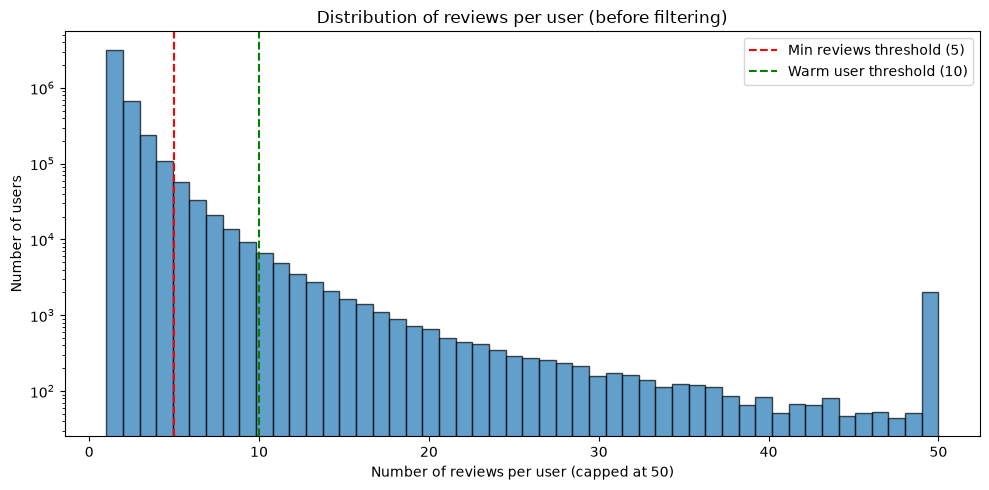

In [16]:
# Analyze distribution of reviews per user before filtering by USER_MIN_REVIEWS
user_counts = df_reviews.groupby("user_id").size()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(user_counts.clip(upper=50), bins=50, edgecolor="black", alpha=0.7)
ax.axvline(USER_MIN_REVIEWS, color="red", linestyle="--",
           label=f"Min reviews threshold ({USER_MIN_REVIEWS})")
ax.axvline(WARM_USER_MIN_REVIEWS, color="green", linestyle="--",
           label=f"Warm user threshold ({WARM_USER_MIN_REVIEWS})")
ax.set_xlabel("Number of reviews per user (capped at 50)")
ax.set_ylabel("Number of users")
ax.set_yscale("log")
ax.set_title("Distribution of reviews per user (before filtering)")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
before_users = df_reviews["user_id"].nunique()
before_reviews = len(df_reviews)
user_counts = df_reviews.groupby("user_id").size()
valid_users = user_counts[user_counts >= USER_MIN_REVIEWS].index
df_reviews = df_reviews[df_reviews["user_id"].isin(valid_users)]
after_users = df_reviews["user_id"].nunique()
after_reviews = len(df_reviews)
removed_users = before_users - after_users
removed_reviews = before_reviews - after_reviews
print(f"Removed {removed_users:,} users with < {USER_MIN_REVIEWS} reviews "
      f"({after_users:,} users remain, {removed_reviews:,} reviews removed)")

## Split train/valid/test with cutoff timestamps

In [92]:
train_end_ts = _date_to_ms(TRAIN_END_CUTOFF_DATE)
valid_end_ts = _date_to_ms(VALID_END_CUTOFF_DATE)
print(f"Train end timestamp: {train_end_ts} ({pd.Timestamp(train_end_ts, unit='ms', tz='UTC')})")
print(f"Valid end timestamp: {valid_end_ts} ({pd.Timestamp(valid_end_ts, unit='ms', tz='UTC')})")

Train end timestamp: 1659312000000 (2022-08-01 00:00:00+00:00)
Valid end timestamp: 1664582400000 (2022-10-01 00:00:00+00:00)


In [93]:
df_reviews_train = df_reviews[df_reviews["timestamp"] <= train_end_ts]
df_reviews_valid = df_reviews[(df_reviews["timestamp"] > train_end_ts) & (df_reviews["timestamp"] <= valid_end_ts)]
df_reviews_test = df_reviews[df_reviews["timestamp"] > valid_end_ts]
print(f"Train reviews: {len(df_reviews_train)}")
print(f"Valid reviews: {len(df_reviews_valid)}")
print(f"Test reviews: {len(df_reviews_test)}")

Train reviews: 1125023
Valid reviews: 168239
Test reviews: 292643


In [94]:
train_users = set(df_reviews_train["user_id"].unique())
df_reviews_valid = df_reviews_valid[df_reviews_valid["user_id"].isin(train_users)]
df_reviews_test = df_reviews_test[df_reviews_test["user_id"].isin(train_users)]
print(f"After filtering out users with no training history:")
print(f"Valid reviews: {len(df_reviews_valid)}")
print(f"Test reviews: {len(df_reviews_test)}")

After filtering out users with no training history:
Valid reviews: 139338
Test reviews: 197706


## Define cold vs. warm users, train items

In [95]:
df_train_users = df_reviews_train.groupby("user_id").size().reset_index(name="num_train")
cold_user_ids: set[str] = set(df_train_users[df_train_users["num_train"] < WARM_USER_MIN_REVIEWS]["user_id"])
warm_user_ids: set[str] = set(df_train_users[df_train_users["num_train"] >= WARM_USER_MIN_REVIEWS]["user_id"])
print(f"Warm users (>= {WARM_USER_MIN_REVIEWS} reviews): {len(warm_user_ids)}")
print(f"Cold users (< {WARM_USER_MIN_REVIEWS} reviews): {len(cold_user_ids)}")

Warm users (>= 10 reviews): 20100
Cold users (< 10 reviews): 136387


In [96]:
train_item_ids = set(df_reviews_train["parent_asin"].unique()) 
print(f"Train items: {len(train_item_ids)}")

Train items: 215358


## Explore train data

In [97]:
def analyze_user_segment(split_name: str, df: pd.DataFrame, warm_min: int = WARM_USER_MIN_REVIEWS):
    split_users = df["user_id"].unique()
    df_split = df.set_index("user_id")

    warm_u = sum(u in warm_user_ids for u in split_users)
    cold_u = sum(u in cold_user_ids for u in split_users)
    total_u = warm_u + cold_u

    warm_r = df_split.loc[df_split.index.isin(warm_user_ids), "parent_asin"].shape[0] if warm_u else 0
    cold_r = df_split.loc[df_split.index.isin(cold_user_ids), "parent_asin"].shape[0] if cold_u else 0
    total_r = warm_r + cold_r

    split_items = set(df["parent_asin"].unique())
    train_items = len(split_items & train_item_ids)
    non_train_items = len(split_items - train_item_ids)

    labels = [f"Warm (≥{warm_min})", f"Cold (<{warm_min})"]
    sizes = [warm_u, cold_u]
    colors = ["#4CAF50", "#FF9800"]
    explode = (0.03, 0.03)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(sizes, labels=labels, autopct="%1.1f%%",
           colors=colors, startangle=90, explode=explode,
           textprops={"fontsize": 11})
    ax.set_title(f"User Segments in {split_name} Set (n={total_u:,})", fontsize=13)
    print(f"Train items: {train_items:,}  |  Non-train items: {non_train_items:,}")
    for k, v_u, v_r in [
        ("warm", warm_u, warm_r), ("cold", cold_u, cold_r)
    ]:
        print(f"{k:5s} users:  {v_u:>7,}  ({v_u/total_u*100:.1f}%)  |  {k:5s} reviews: {v_r:>7,}  ({v_r/total_r*100:.1f}%)")

Train items: 215,358  |  Non-train items: 0
warm  users:   20,100  (12.8%)  |  warm  reviews: 428,225  (38.1%)
cold  users:  136,387  (87.2%)  |  cold  reviews: 696,798  (61.9%)
Interactions per user 7.18924255688971
Sparsity 0.9999666172486887


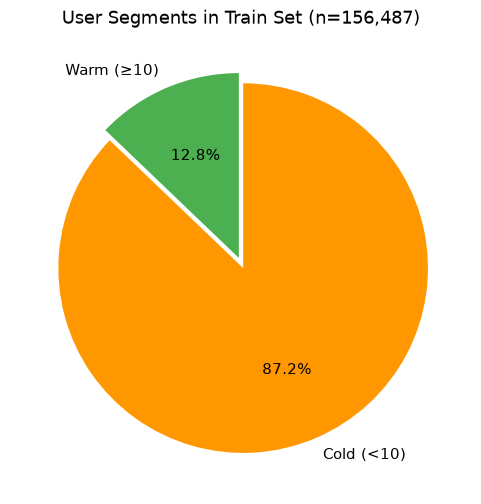

In [98]:
analyze_user_segment("Train", df_reviews_train)
print('Interactions per user', len(df_reviews_train) / len(df_reviews_train['user_id'].unique()))
print('Sparsity', 1 - len(df_reviews_train) / (len(df_reviews_train['user_id'].unique()) * len(df_reviews_train['parent_asin'].unique())))

## Explore valid data

Train items: 38,301  |  Non-train items: 14,525
warm  users:    6,818  (14.4%)  |  warm  reviews:  40,855  (29.3%)
cold  users:   40,391  (85.6%)  |  cold  reviews:  98,483  (70.7%)


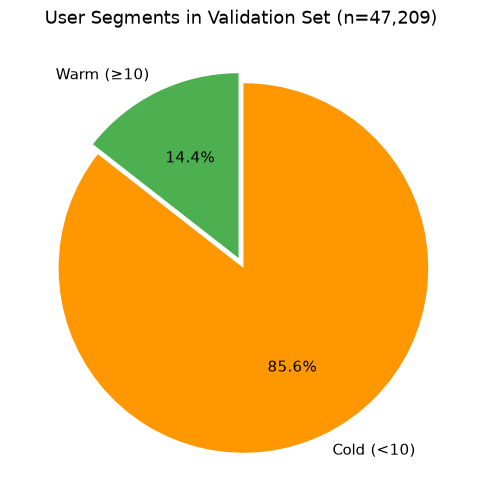

In [99]:
valid_stats = analyze_user_segment("Validation", df_reviews_valid)

## Explore test data

Train items: 40,594  |  Non-train items: 26,149
warm  users:    7,299  (13.1%)  |  warm  reviews:  46,742  (23.6%)
cold  users:   48,295  (86.9%)  |  cold  reviews: 150,964  (76.4%)


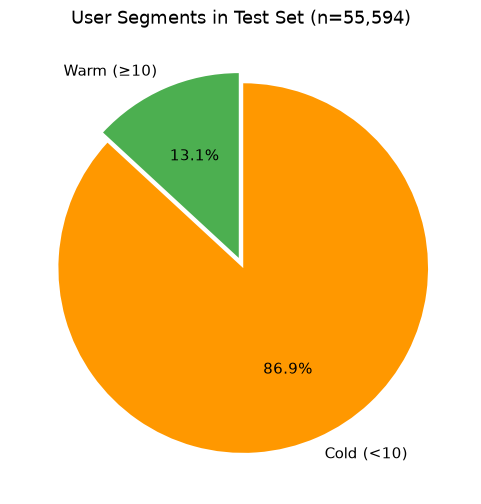

In [100]:
test_stats = analyze_user_segment("Test", df_reviews_test)